# Visualization and more data transformation.
Parts of this need to be added to the previous notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Combine all daily datasets into one

In [12]:
import pandas as pd
import glob
import os

# 1. Define the directory path
path = 'daily_data' 

# 2. Find all CSV files in that folder
all_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Read each file and store in a list
df_list = []
for filename in all_files:
    df = pd.read_csv(filename)
    # Optional: Add a column to track which file the data came from
    df['source_file'] = os.path.basename(filename)
    df_list.append(df)

# 4. Combine everything into one master DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

print(combined_df.head())

    timestamp ticker    open    high     low   close       volume      vwap  \
0  2021-04-23   AAPL  132.16  135.12  132.16  134.32   78666779.0  134.1622   
1  2021-04-26   AAPL  134.83  135.06  133.56  134.72   66888509.0  134.5418   
2  2021-04-27   AAPL  135.01  135.41  134.11  134.39   66015804.0  134.5907   
3  2021-04-28   AAPL  134.31  135.02  133.08  133.58  107746597.0  134.6526   
4  2021-04-29   AAPL  136.47  137.07  132.45  133.48  151100953.0  134.1771   

   transactions     source_file  
0        519533  aapl_daily.csv  
1        484069  aapl_daily.csv  
2        480003  aapl_daily.csv  
3        783355  aapl_daily.csv  
4       1059387  aapl_daily.csv  


In [13]:
combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,source_file
0,2021-04-23,AAPL,132.160,135.120,132.160,134.32,7.866678e+07,134.1622,519533,aapl_daily.csv
1,2021-04-26,AAPL,134.830,135.060,133.560,134.72,6.688851e+07,134.5418,484069,aapl_daily.csv
2,2021-04-27,AAPL,135.010,135.410,134.110,134.39,6.601580e+07,134.5907,480003,aapl_daily.csv
3,2021-04-28,AAPL,134.310,135.020,133.080,133.58,1.077466e+08,134.6526,783355,aapl_daily.csv
4,2021-04-29,AAPL,136.470,137.070,132.450,133.48,1.511010e+08,134.1771,1059387,aapl_daily.csv
...,...,...,...,...,...,...,...,...,...,...
37478,2026-04-15,MRK,119.795,120.250,116.635,117.90,7.689371e+06,117.9775,106973,mrk_daily.csv
37479,2026-04-16,MRK,117.130,117.850,114.710,115.46,1.139989e+07,115.7336,134254,mrk_daily.csv
37480,2026-04-17,MRK,115.560,119.200,115.560,119.07,1.619490e+07,118.3044,129356,mrk_daily.csv
37481,2026-04-20,MRK,119.150,119.360,116.750,117.10,7.391725e+06,117.7670,91048,mrk_daily.csv


In [18]:
combined_df['ticker'].value_counts()

ticker
AAPL     1254
JNJ      1254
QQQ      1254
COST     1254
MSFT     1254
AMZN     1254
TSLA     1254
CVX      1254
DIA      1254
HD       1254
UNH      1254
PFE      1254
GE       1254
CAT      1254
GOOGL    1254
JPM      1254
SBUX     1254
NFLX     1254
SPY      1254
UPS      1254
XOM      1254
BAC      1254
NVDA     1254
GS       1254
NKE      1254
MS       1254
WMT      1254
BA       1254
MRK      1254
META     1117
Name: count, dtype: int64

# Four stocks

In [23]:
# Four Stocks
aapl_daily = pd.read_csv('daily_data/aapl_daily.csv')
nvda_daily = pd.read_csv('daily_data/nvda_daily.csv')
amzn_daily = pd.read_csv('daily_data/amzn_daily.csv')
googl_daily = pd.read_csv('daily_data/googl_daily.csv')

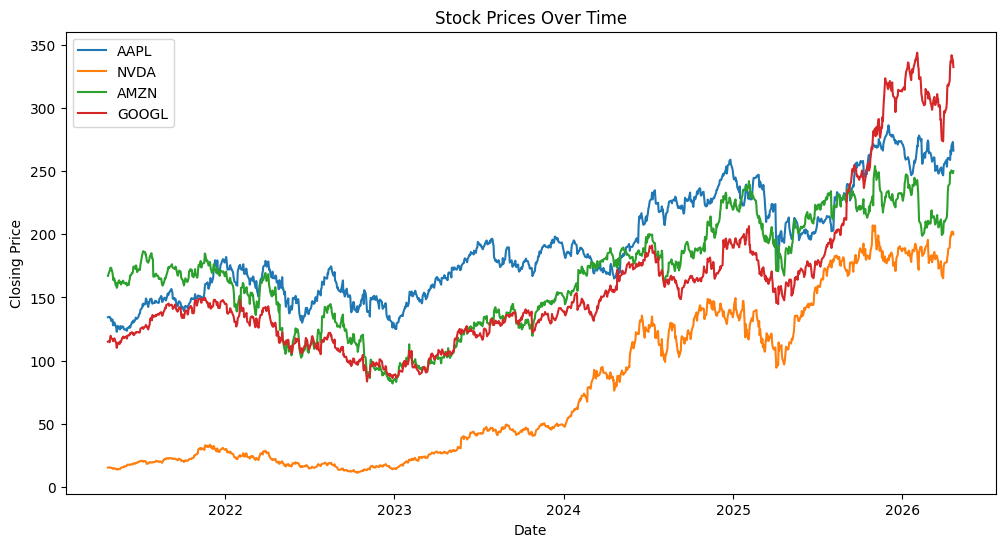

In [26]:
import matplotlib.pyplot as plt

# Make sure timestamps are datetime
for df in [aapl_daily, nvda_daily, amzn_daily, googl_daily]:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.sort_values('timestamp', inplace=True)

# Plot
plt.figure(figsize=(12,6))

plt.plot(aapl_daily['timestamp'], aapl_daily['close'], label='AAPL')
plt.plot(nvda_daily['timestamp'], nvda_daily['close'], label='NVDA')
plt.plot(amzn_daily['timestamp'], amzn_daily['close'], label='AMZN')
plt.plot(googl_daily['timestamp'], googl_daily['close'], label='GOOGL')

plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Stock Prices Over Time')
plt.legend()

plt.show()

# Apple - SMA (temporary, will soon add this step to previous notebooks to avoid having to do it manually every time)


In [27]:
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387
...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032


In [36]:
aapl_daily['sma20'] = aapl_daily['close'].rolling(window=20).mean()
aapl_daily['sma50'] = aapl_daily['close'].rolling(window=50).mean()
aapl_daily['sma100'] = aapl_daily['close'].rolling(window=100).mean()
aapl_daily['sma150'] = aapl_daily['close'].rolling(window=150).mean()

aapl_daily

aapl_daily_with_sma = aapl_daily.dropna()
aapl_daily_with_sma

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,sma20,sma50,sma100,sma150
149,2021-11-23,AAPL,161.120,161.800,159.0601,161.41,9.602290e+07,160.3405,712377,152.3150,147.8676,147.9696,141.806067
150,2021-11-24,AAPL,160.750,162.140,159.6400,161.94,6.926362e+07,161.1093,505241,152.9695,148.1258,148.1688,141.990200
151,2021-11-26,AAPL,159.565,160.450,156.3600,156.81,7.694075e+07,157.8439,666767,153.1815,148.2862,148.2912,142.137467
152,2021-11-29,AAPL,159.370,161.190,158.7901,160.24,8.849822e+07,160.1333,663948,153.7035,148.5698,148.4612,142.309800
153,2021-11-30,AAPL,159.985,165.520,159.9200,165.30,1.739581e+08,163.7750,1139625,154.5205,149.0170,148.6631,142.521267
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.160,266.560,257.8100,266.43,4.991351e+07,264.1551,728560,254.6495,260.8112,264.5789,262.112533
1250,2026-04-16,AAPL,266.800,267.160,261.2700,263.40,4.332311e+07,263.4178,635080,255.3225,260.6896,264.5273,262.356600
1251,2026-04-17,AAPL,266.960,272.300,266.7200,270.23,6.143623e+07,269.8735,723488,256.3860,260.5644,264.5671,262.624600
1252,2026-04-20,AAPL,270.330,274.275,270.2900,273.05,3.658260e+07,272.6888,541032,257.6390,260.5072,264.5827,262.884467


/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_92698/2411933263.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aapl_daily_with_sma['Date'] = pd.to_datetime(aapl_daily_with_sma['timestamp'])


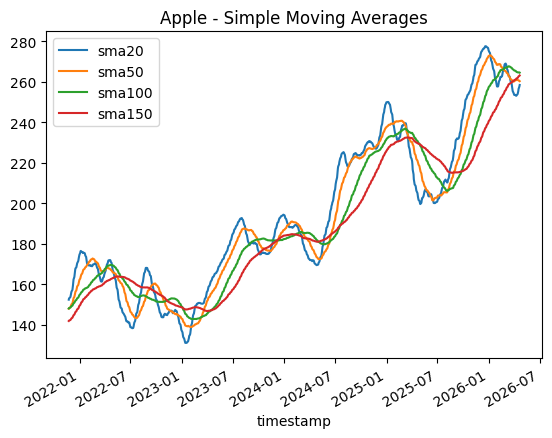

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure the date column is a datetime object
aapl_daily_with_sma['Date'] = pd.to_datetime(aapl_daily_with_sma['timestamp'])

# 2. Plot all 4 columns on the same chart using the Date column as the x-axis
aapl_daily_with_sma.plot(x='timestamp', y=['sma20', 'sma50', 'sma100', 'sma150'])
plt.title('Apple - Simple Moving Averages')
plt.show()

# Data Transformation

In [44]:
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,sma20,sma50,sma100,sma150
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533,NaN,NaN,NaN,NaN
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069,NaN,NaN,NaN,NaN
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003,NaN,NaN,NaN,NaN
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355,NaN,NaN,NaN,NaN
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560,254.6495,260.8112,264.5789,262.112533
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080,255.3225,260.6896,264.5273,262.356600
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488,256.3860,260.5644,264.5671,262.624600
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032,257.6390,260.5072,264.5827,262.884467


In [47]:
aapl_daily['close_daily_change'] = aapl_daily['close'].diff()
aapl_daily['close_daily_change_abs'] = aapl_daily['close_daily_change'].abs()

In [48]:
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,sma20,sma50,sma100,sma150,close_vs_prev,close_daily_change,close_daily_change_abs
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069,NaN,NaN,NaN,NaN,0.40,0.40,0.40
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003,NaN,NaN,NaN,NaN,-0.33,-0.33,0.33
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355,NaN,NaN,NaN,NaN,-0.81,-0.81,0.81
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387,NaN,NaN,NaN,NaN,-0.10,-0.10,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560,254.6495,260.8112,264.5789,262.112533,7.60,7.60,7.60
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080,255.3225,260.6896,264.5273,262.356600,-3.03,-3.03,3.03
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488,256.3860,260.5644,264.5671,262.624600,6.83,6.83,6.83
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032,257.6390,260.5072,264.5827,262.884467,2.82,2.82,2.82


In [49]:
# Total absolute daily change across all - Rough indicator of volatility?
aapl_daily['close_daily_change_abs'].sum()

np.float64(2836.17)

In [53]:
# Average daily change (non-absolute)
aapl_daily['close_daily_change'].mean()

np.float64(0.10522745411013569)

In [54]:
# Average adjusted for total days (this needs to be more dynamic to dataframe size)
(aapl_daily['close_daily_change'].mean()) * 1254

np.float64(131.95522745411014)

In [57]:
# What was the total change from beginning to end of the dataset?
aapl_daily['close'].iloc[-1] - aapl_daily['close'].iloc[0]

np.float64(131.85000000000002)

In [55]:
# Median daily change (non-absolute)
aapl_daily['close_daily_change'].median()

np.float64(0.17000000000001592)

In [56]:
# Median adjusted for total days (this needs to be more dynamic to dataframe size)
(aapl_daily['close_daily_change'].median()) * 1254

np.float64(213.18000000001996)

Should all of the above be instead rendered as percentages? Probably so considering assignment asks for those.

In [58]:
# Percentage change ( (Value_Curr - Value_Prev) / Value_Prev )
aapl_daily['close_daily_pct_change'] = aapl_daily['close'].pct_change()
aapl_daily['close_daily_abs_pct_change'] = aapl_daily['close_daily_pct_change'].abs()

In [63]:
# Average pct daily change (non-absolute)
aapl_daily['close_daily_pct_change'].mean()

np.float64(0.0006949308393557564)

In [65]:
# Average pct daily change adjusted for total days (this needs to be more dynamic to dataframe size)
(aapl_daily['close_daily_pct_change'].mean()) * 1254

np.float64(0.8714432725521185)

In [67]:
# Percentage change from beginning to end
pct_change = (aapl_daily['close'].iloc[-1] / aapl_daily['close'].iloc[0] - 1) * 100
pct_change

np.float64(98.16110780226327)

# Columns for daily changes 2,3,4,5,6 pct

In [73]:
aapl_daily['pct_dly_change_2'] = (aapl_daily['close_daily_pct_change'] >= 2).astype(int)
aapl_daily['pct_dly_change_3'] = (aapl_daily['close_daily_pct_change'] >= 3).astype(int)
aapl_daily['pct_dly_change_4'] = (aapl_daily['close_daily_pct_change'] >= 4).astype(int)
aapl_daily['pct_dly_change_5'] = (aapl_daily['close_daily_pct_change'] >= 5).astype(int)
aapl_daily['pct_dly_change_6'] = (aapl_daily['close_daily_pct_change'] >= 6).astype(int)

# Create binary column: 1 if next row is > 0, else 0
#df['next_pos'] = (df['value'].shift(-1) > 0).astype(int)

aapl_daily['next_day_pos'] = (aapl_daily['close_daily_change'].shift(-1) > 0).astype(int)
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,sma20,...,close_daily_change,close_daily_change_abs,close_daily_pct_change,close_daily_abs_pct_change,pct_dly_change_2,pct_dly_change_3,pct_dly_change_4,pct_dly_change_5,pct_dly_change_6,next_day_pos
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533,NaN,...,NaN,NaN,NaN,NaN,0,0,0,0,0,1
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069,NaN,...,0.40,0.40,0.002978,0.002978,0,0,0,0,0,0
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003,NaN,...,-0.33,0.33,-0.002450,0.002450,0,0,0,0,0,0
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355,NaN,...,-0.81,0.81,-0.006027,0.006027,0,0,0,0,0,0
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387,NaN,...,-0.10,0.10,-0.000749,0.000749,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560,254.6495,...,7.60,7.60,0.029363,0.029363,0,0,0,0,0,0
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080,255.3225,...,-3.03,3.03,-0.011373,0.011373,0,0,0,0,0,1
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488,256.3860,...,6.83,6.83,0.025930,0.025930,0,0,0,0,0,1
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032,257.6390,...,2.82,2.82,0.010436,0.010436,0,0,0,0,0,0


In [77]:
aapl_daily['pct_dly_change_2'].value_counts()

pct_dly_change_2
0    1254
Name: count, dtype: int64

Weird, seems AAPL never had a signed daily change of at least 2%. Is AAPL just an unusually stable stock or do I need to find another source?

Also need to add, as a more robust indicator of volatility, daily change (and abs change) vs average of all stocks.

Measure sums of daily changes and daily absolute changes against the overall change during the entire span.

Would it also be useful to have yearly and monthly changes?

In [ ]:
# Percentage change ( (Value_Curr - Value_Prev) / Value_Prev )
#df['Percent_Change'] = df['Value'].pct_change()

# Old

In [2]:
# Apple
aapl_daily = pd.read_csv('datasets/aapl_daily.csv')
aapl_daily

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-04-23,AAPL,132.16,135.120,132.16,134.32,7.866678e+07,134.1622,519533
1,2021-04-26,AAPL,134.83,135.060,133.56,134.72,6.688851e+07,134.5418,484069
2,2021-04-27,AAPL,135.01,135.410,134.11,134.39,6.601580e+07,134.5907,480003
3,2021-04-28,AAPL,134.31,135.020,133.08,133.58,1.077466e+08,134.6526,783355
4,2021-04-29,AAPL,136.47,137.070,132.45,133.48,1.511010e+08,134.1771,1059387
...,...,...,...,...,...,...,...,...,...
1249,2026-04-15,AAPL,258.16,266.560,257.81,266.43,4.991351e+07,264.1551,728560
1250,2026-04-16,AAPL,266.80,267.160,261.27,263.40,4.332311e+07,263.4178,635080
1251,2026-04-17,AAPL,266.96,272.300,266.72,270.23,6.143623e+07,269.8735,723488
1252,2026-04-20,AAPL,270.33,274.275,270.29,273.05,3.658260e+07,272.6888,541032


In [ ]:
aapl_daily

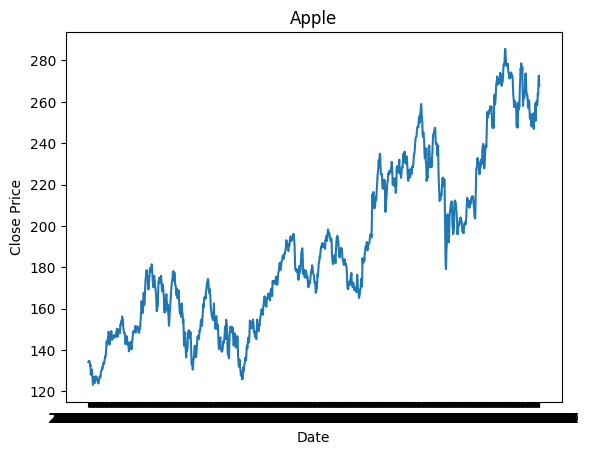

In [7]:
plt.plot(aapl_daily['timestamp'], aapl_daily['vwap'])
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Apple')
plt.show()